# 🎵 Music Recommendation System — Exploratory Data Analysis

This notebook performs an end-to-end exploratory data analysis on the Spotify music dataset.
We load four datasets, inspect their structure, engineer features, and visualize key patterns.

## 📦 Imports

In [3]:
import sys
!{sys.executable} -m pip install wordcloud seaborn plotly


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS
sns.set_theme(style='darkgrid')
%matplotlib inline

---
## 1️⃣ Load Datasets

In [6]:
# Step 1: Read the main dataset
data = pd.read_csv('../data/data.csv')

# Step 2: Read the genre dataset
genre_data = pd.read_csv('../data/data_by_genres.csv')

# Step 3: Read the year dataset
year_data = pd.read_csv('../data/data_by_year.csv')

# Step 4: Read the artist dataset
artist_data = pd.read_csv('../data/data_by_artist.csv')

---
## 2️⃣ Preview Data — First 2 Rows

In [7]:
print("── data ──")
data.head(2)

── data ──


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936


In [8]:
print("── genre_data ──")
genre_data.head(2)

── genre_data ──


,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.3616,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.1310,-16.854000,0.076817,120.285667,0.221750,52.500000,5


In [9]:
print("── year_data ──")
year_data.head(2)

── year_data ──


,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.20571,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.24072,-19.275282,0.116655,100.884521,0.535549,0.140845,10


In [10]:
print("── artist_data ──")
artist_data.head(2)

── artist_data ──


,mode,count,acousticness,artists,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,9,0.590111,"""Cats"" 1981 Original London Cast",0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448,0.210389,117.518111,0.389500,38.333333,5
1,1,26,0.862538,"""Cats"" 1983 Broadway Cast",0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690,0.176212,103.044154,0.268865,30.576923,5


---
## 3️⃣ Dataset Info

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [12]:
genre_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2973 entries, 0 to 2972
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mode              2973 non-null   int64  
 1   genres            2973 non-null   object 
 2   acousticness      2973 non-null   float64
 3   danceability      2973 non-null   float64
 4   duration_ms       2973 non-null   float64
 5   energy            2973 non-null   float64
 6   instrumentalness  2973 non-null   float64
 7   liveness          2973 non-null   float64
 8   loudness          2973 non-null   float64
 9   speechiness       2973 non-null   float64
 10  tempo             2973 non-null   float64
 11  valence           2973 non-null   float64
 12  popularity        2973 non-null   float64
 13  key               2973 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 325.3+ KB


---
## 4️⃣ Feature Engineering — `decade` Column

In [13]:
# Create a decade column using apply() and a lambda function
# e.g., year 1984 → 1980, year 2003 → 2000
data['decade'] = data['year'].apply(lambda year: (year // 10) * 10)

print("Sample — year vs decade:")
data[['year', 'decade']].head()

Sample — year vs decade:


,year,decade
0,1921,1920
1,1921,1920
2,1921,1920
3,1921,1920
4,1921,1920


---
## 5️⃣ Distribution of Tracks Across Decades

C:\Users\HP\AppData\Local\Temp\ipykernel_22032\1347028717.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


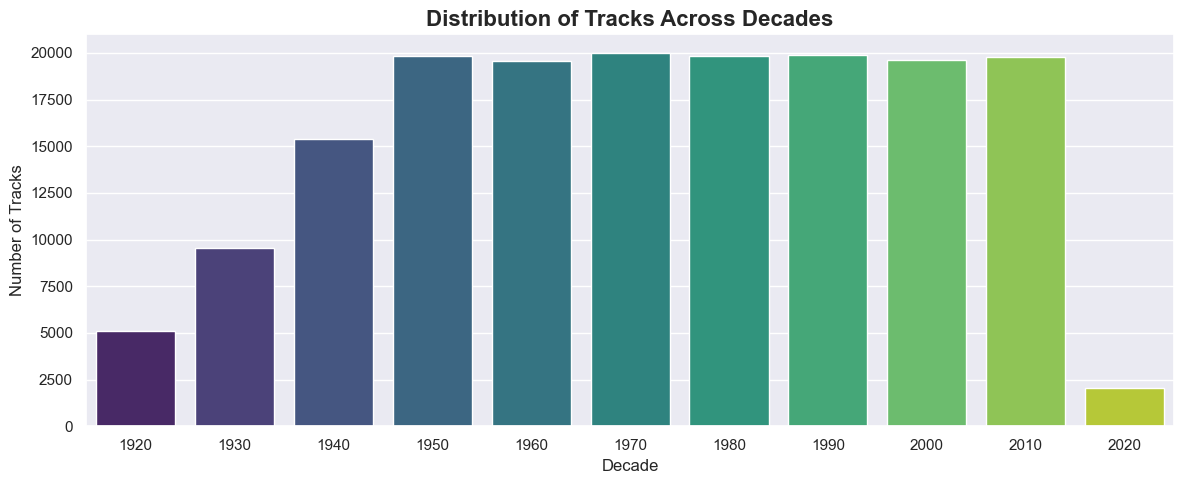

In [14]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=data,
    x='decade',
    palette='viridis',
    order=sorted(data['decade'].unique())
)
plt.title('Distribution of Tracks Across Decades', fontsize=16, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()

---
## 6️⃣ Trend of Various Sound Features Over Decades

In [15]:
sound_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'valence']

fig = px.line(
    year_data,
    x='year',
    y=sound_features,
    title='Trend of various sound features over decades'
)
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Feature Value',
    legend_title='Sound Feature'
)
fig.show()

---
## 7️⃣ Trend of Loudness Over Decades

In [16]:
fig = px.line(
    year_data,
    x='year',
    y='loudness',
    title='Trend of loudness over decades'
)
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Loudness (dB)'
)
fig.show()

---
## 8️⃣ Sound Features for Top 10 Genres by Popularity

In [17]:
# Identify the top 10 genres based on popularity
top10_genres = genre_data.nlargest(10, 'popularity')

fig = px.bar(
    top10_genres,
    x='genres',
    y=['valence', 'energy', 'danceability', 'acousticness'],
    barmode='group',
    title='Trend of various sound features over top 10 genres'
)
fig.update_layout(
    xaxis_title='Genre',
    yaxis_title='Feature Value',
    legend_title='Sound Feature',
    xaxis_tickangle=-30
)
fig.show()

---
## 9️⃣ Word Cloud — Genres

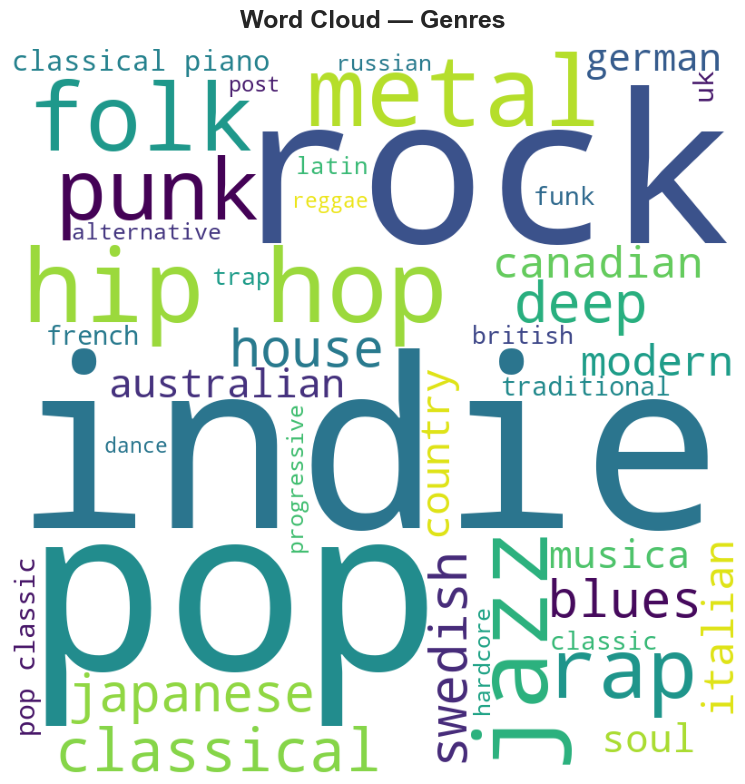

In [18]:
# Build a single string of all genre names
comment_words = ' '.join(genre_data['genres'].dropna().astype(str).values)
stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stopwords,
    max_words=40,
    min_font_size=10
).generate(comment_words)

plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud — Genres', fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 🔟 Word Cloud — Artists

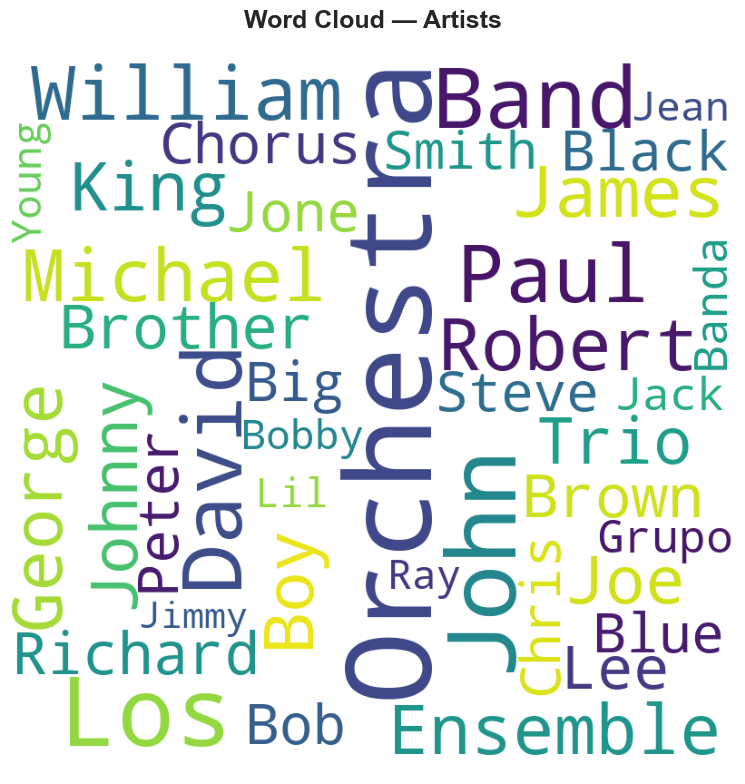

In [19]:
# Build a single string of all artist names
comment_words = ' '.join(artist_data['artists'].dropna().astype(str).values)
stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stopwords,
    min_word_length=3,
    max_words=40,
    min_font_size=10
).generate(comment_words)

plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud — Artists', fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 1️⃣1️⃣ Top 10 Artists — Most Songs Produced

In [20]:
# Top 10 artists by number of songs produced
top10_most_song_produced_artists = artist_data.nlargest(10, 'count')

top10_most_song_produced_artists[['count', 'artists']].sort_values('count', ascending=False)

,count,artists
8367,3169,Francisco Canaro
28561,2422,Эрнест Хемингуэй
28560,2136,Эрих Мария Ремарк
8434,1459,Frank Sinatra
10714,1256,Ignacio Corsini
27109,1200,Vladimir Horowitz
1682,1146,Arturo Toscanini
2707,1103,Billie Holiday
12378,1061,Johnny Cash
7426,1023,Elvis Presley


---
## 1️⃣2️⃣ Top 10 Artists — Highest Popularity Score

In [21]:
# Top 10 artists by popularity score
top10_popular_artists = artist_data.nlargest(10, 'popularity')

top10_popular_artists[['popularity', 'artists']].sort_values('popularity', ascending=False)

,popularity,artists
20966,93.0,Ritt Momney
14354,92.0,Lele Pons
15070,90.0,Los Legendarios
11764,89.0,Jerry Di
7463,88.0,Emilee
23687,88.0,Surf Mesa
28263,88.0,salem ilese
213,87.0,A7S
2343,86.0,Beltito
14378,86.0,Lenny Santos


---
## ✅ Conclusion

This exploratory analysis of the Spotify dataset has revealed several key insights about music trends over the decades:

### 📊 Track Distribution
- The dataset is heavily skewed toward **modern music (2000s–2020s)**, with an exponential increase in the number of tracks per decade — reflecting both the digitization of music and the explosive growth of streaming platforms.

### 🎵 Sound Feature Trends
- **Acousticness** has declined sharply over time, driven by the rise of electric and electronic music production.
- **Energy** and **danceability** have steadily increased, reflecting the dominance of up-tempo genres like pop, hip-hop, and EDM in recent decades.
- **Instrumentalness** has dropped significantly since the 1960s, as vocal-driven tracks became the industry standard.
- **Valence** (musical positivity) has shown a slight downward trend in recent years, suggesting that modern music trends toward more emotionally complex or darker tones.

### 🔊 Loudness
- Loudness has increased dramatically from the 1920s to the 2000s — a well-documented phenomenon known as the **"Loudness War"**, where mastering engineers increasingly maximized volume to stand out on radio and streaming platforms.

### 🎸 Genre Insights
- The top 10 genres by popularity are dominated by **mainstream pop and hip-hop adjacent genres**, which score high on energy and danceability but lower on acousticness.
- The genre word cloud highlights a rich diversity in musical styles, ranging from classical and jazz to electronic subgenres.

### 🎤 Artist Insights
- The most **prolific artists** (by song count) are not always the most **popular**, indicating that popularity is driven more by hit quality than sheer volume of output.
- The top popular artists tend to be globally recognized mainstream acts, consistent with streaming platform biases toward well-known names.

### 🚀 Next Steps
These findings lay a strong foundation for building a music recommendation system. The audio features extracted here — especially `energy`, `danceability`, `valence`, and `acousticness` — will serve as the primary dimensions for computing song similarity in the recommendation engine.